# Random Forest — Modelo Principal e Experimento com USD/BRL(t)

Notebook modular para execução do Random Forest mantendo a mesma estrutura experimental do notebook de Regressão Linear. A única alteração entre as especificações é a inclusão de `USD/BRL(t)` como variável explicativa no experimento alternativo.

## Etapa 1 — Configuração dos caminhos e experimento

`EXPERIMENTO_USD_T = False` executa o **modelo principal** com as 9 variáveis originais.

`EXPERIMENTO_USD_T = True` executa o **experimento alternativo**, adicionando `USD/BRL(t)`.

O mesmo arquivo-base pode ser utilizado nas duas especificações; o que muda é a seleção das variáveis e a pasta de resultados.

In [30]:
from pathlib import Path

# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

EXPERIMENTO_USD_T = True

PROJECT_ROOT = Path(r"C:\Projetos\PTAX_PREDICTION_MBA_TCC")

PATH_FILE_PRINCIPAL = (
    PROJECT_ROOT
    / "dados"
    / "tratado"
    / "consolidado_sem_nulos_final_usdt1.csv"
)

PATH_FILE_ALTERNATIVO = (
    PROJECT_ROOT
    / "dados"
    / "tratado"
    / "consolidado_sem_nulos_final_usdt1.csv"
)

PATH_SAVE_PRINCIPAL = (
    PROJECT_ROOT
    / "resultados"
    / "random_forest"
    / "modelo_principal"
)

PATH_SAVE_ALTERNATIVO = (
    PROJECT_ROOT
    / "resultados"
    / "random_forest"
    / "experimento_usd_t"
)

if EXPERIMENTO_USD_T:
    PATH_FILE = PATH_FILE_ALTERNATIVO
    PATH_TO_SAVE = PATH_SAVE_ALTERNATIVO
    NOME_EXPERIMENTO = "Experimento com USD/BRL(t)"
else:
    PATH_FILE = PATH_FILE_PRINCIPAL
    PATH_TO_SAVE = PATH_SAVE_PRINCIPAL
    NOME_EXPERIMENTO = "Modelo principal"

PATH_TO_SAVE.mkdir(parents=True, exist_ok=True)

print(f"Experimento: {NOME_EXPERIMENTO}")
print(f"Base: {PATH_FILE}")
print(f"Resultados: {PATH_TO_SAVE}")


Experimento: Experimento com USD/BRL(t)
Base: C:\Projetos\PTAX_PREDICTION_MBA_TCC\dados\tratado\consolidado_sem_nulos_final_usdt1.csv
Resultados: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\random_forest\experimento_usd_t


## Etapa 2 — Importação das bibliotecas

In [31]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from arquivos_apoio.funcoes_apoio import dividir_treino_teste_tcc

## Etapa 3 — Carregamento, preparação da base e divisão temporal treino/teste

A divisão preserva a ordem temporal, utiliza 80% das observações para treinamento e 20% para teste e não utiliza `Data` como variável explicativa. O índice temporal é mantido como `DatetimeIndex`.

In [32]:
X_train, y_train, X_test, y_test = dividir_treino_teste_tcc(PATH_FILE, incluir_usd_t=EXPERIMENTO_USD_T)
target = "USD_BRL_t1"

variaveis_base = [
        "Selic",
        "IPCA",
        "PIB",
        "Exportacoes",
        "Importacoes",
        "FEDFUNDS",
        "IBOV",
        "SP500",
        "Petroleo"
    ]

variaveis_explicativas = variaveis_base.copy()

if EXPERIMENTO_USD_T:
    variaveis_explicativas.append("USD/BRL")


[OK] Base carregada.
[INFO] Dimensões iniciais: (2600, 11)
[OK] Índice convertido para DatetimeIndex.
[OK] Base ordenada cronologicamente.
[OK] Não existem valores nulos.
[OK] Não existem valores infinitos.

DIVISÃO TREINO / TESTE
[INFO] Configuração: Experimento com USD/BRL(t)
[INFO] Variáveis explicativas: 10
[INFO] Variáveis: ['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS', 'IBOV', 'SP500', 'Petroleo', 'USD/BRL']
[INFO] Observações totais: 2600
[INFO] Treino: 2080 (80.0%)
[INFO] Teste: 520 (20.0%)
[INFO] Período treino: 2016-05-02 a 2024-04-24
[INFO] Período teste: 2024-04-25 a 2026-04-29
[OK] Ordem temporal preservada.
[OK] Sem sobreposição temporal.
[OK] Target: USD_BRL_t1


## Etapa 5 — Validação final dos dados antes do treinamento

In [33]:
print("=" * 70)
print("VALIDAÇÃO DOS DADOS")
print("=" * 70)

print(f"[OK] X_train é DataFrame: {isinstance(X_train, pd.DataFrame)}")
print(f"[OK] X_test é DataFrame:  {isinstance(X_test, pd.DataFrame)}")
print(f"[OK] y_train é Series:    {isinstance(y_train, pd.Series)}")
print(f"[OK] y_test é Series:     {isinstance(y_test, pd.Series)}")

if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "X_train e X_test possuem colunas diferentes ou em ordem diferente."
    )

if X_train.isna().any().any() or X_test.isna().any().any():
    raise ValueError("Existem NaN nas variáveis explicativas.")

if y_train.isna().any() or y_test.isna().any():
    raise ValueError("Existem NaN no target.")

if np.isinf(X_train.select_dtypes(include=np.number)).any().any():
    raise ValueError("Existem infinitos em X_train.")

if np.isinf(X_test.select_dtypes(include=np.number)).any().any():
    raise ValueError("Existem infinitos em X_test.")

if np.isinf(y_train).any() or np.isinf(y_test).any():
    raise ValueError("Existem infinitos no target.")

if not isinstance(X_train.index, pd.DatetimeIndex):
    raise ValueError("X_train deve possuir DatetimeIndex.")

if not isinstance(X_test.index, pd.DatetimeIndex):
    raise ValueError("X_test deve possuir DatetimeIndex.")

if X_train.index.max() >= X_test.index.min():
    raise ValueError("Existe sobreposição temporal entre treino e teste.")

print("[OK] Não existem NaN ou valores infinitos.")
print("[OK] Variáveis de treino e teste são idênticas.")
print("[OK] Índices temporais validados.")
print("[OK] Sem sobreposição temporal.")


VALIDAÇÃO DOS DADOS
[OK] X_train é DataFrame: True
[OK] X_test é DataFrame:  True
[OK] y_train é Series:    True
[OK] y_test é Series:     True
[OK] Não existem NaN ou valores infinitos.
[OK] Variáveis de treino e teste são idênticas.
[OK] Índices temporais validados.
[OK] Sem sobreposição temporal.


## Etapa 6 — Configuração e treinamento do Random Forest

In [34]:
modelo_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("CONFIGURAÇÃO DO RANDOM FOREST")
print("n_estimators      = 500")
print("max_depth         = None")
print("min_samples_split = 2")
print("min_samples_leaf  = 1")
print("max_features      = 1.0")
print("random_state      = 42")
print("n_jobs            = -1")

print("\n[INFO] Treinando Random Forest...")

modelo_rf.fit(
    X_train,
    y_train
)

print("[OK] Random Forest treinado.")


CONFIGURAÇÃO DO RANDOM FOREST
n_estimators      = 500
max_depth         = None
min_samples_split = 2
min_samples_leaf  = 1
max_features      = 1.0
random_state      = 42
n_jobs            = -1

[INFO] Treinando Random Forest...
[OK] Random Forest treinado.


## Etapa 7 — Geração das previsões

In [35]:
y_pred_train = modelo_rf.predict(
    X_train
)

y_pred_test = modelo_rf.predict(
    X_test
)

print("[OK] Previsões de treino e teste geradas.")

previsoes_treino = pd.DataFrame({
    "Data": X_train.index,
    "Real": y_train.values,
    "Previsto": y_pred_train
})

previsoes_teste = pd.DataFrame({
    "Data": X_test.index,
    "Real": y_test.values,
    "Previsto": y_pred_test
})

display(previsoes_teste.head())


[OK] Previsões de treino e teste geradas.


,Data,Real,Previsto
0,2024-04-25,5.1586,5.149843
1,2024-04-26,5.1155,5.140826
2,2024-04-29,5.1170,5.144577
3,2024-04-30,5.1939,5.141649
4,2024-05-01,5.1944,5.189290


## Etapa 8 — Diagnóstico dos resíduos e valores reais × previstos

Assim como na Regressão Linear, são gerados os diagnósticos visuais que podem ser aplicados ao Random Forest:

- resíduos no conjunto de treino;
- resíduos no conjunto de teste;
- valores reais × previstos no conjunto de teste.

Os resíduos são calculados como:

$$
e_t = y_t - \hat{y}_t
$$

Esses gráficos permitem manter a análise visual dos modelos comparável.

In [36]:
# ============================================================
# CÁLCULO DOS RESÍDUOS
# ============================================================

residuos_treino = (
    y_train.to_numpy(dtype=float)
    - y_pred_train
)

residuos_teste = (
    y_test.to_numpy(dtype=float)
    - y_pred_test
)

residuos_treino_df = pd.DataFrame({
    "Data": X_train.index,
    "Real": y_train.to_numpy(dtype=float),
    "Previsto": y_pred_train,
    "Residuo": residuos_treino
})

residuos_teste_df = pd.DataFrame({
    "Data": X_test.index,
    "Real": y_test.to_numpy(dtype=float),
    "Previsto": y_pred_test,
    "Residuo": residuos_teste
})

display(residuos_teste_df.head())

print("[OK] Resíduos calculados para treino e teste.")

,Data,Real,Previsto,Residuo
0,2024-04-25,5.1586,5.149843,0.008757
1,2024-04-26,5.1155,5.140826,-0.025326
2,2024-04-29,5.1170,5.144577,-0.027577
3,2024-04-30,5.1939,5.141649,0.052251
4,2024-05-01,5.1944,5.189290,0.005109


[OK] Resíduos calculados para treino e teste.


### Etapa 8.1 — Gráfico dos resíduos — Treino

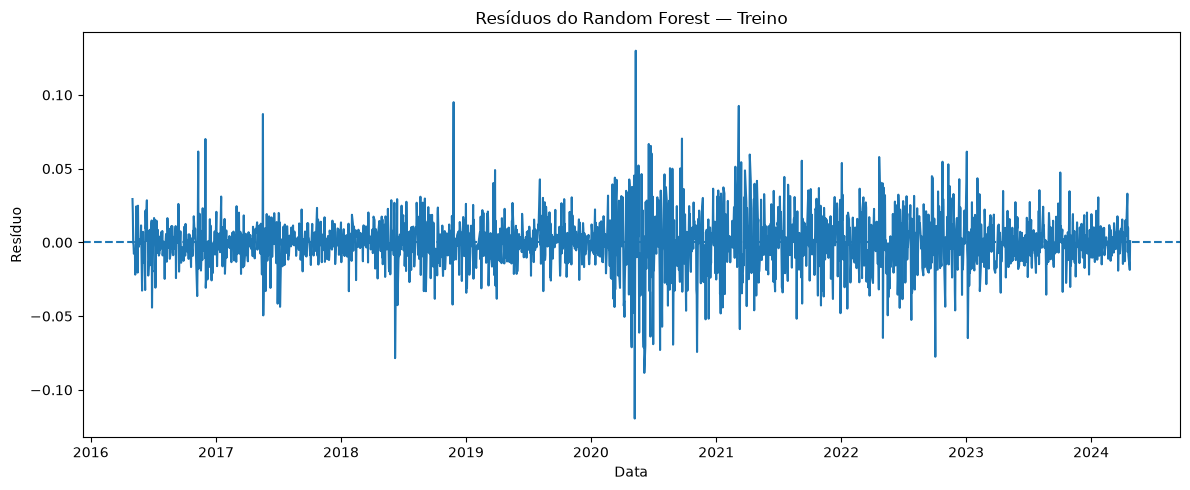

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    X_train.index,
    residuos_treino
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Resíduos do Random Forest — Treino"
)

plt.xlabel("Data")
plt.ylabel("Resíduo")

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "grafico_residuos_treino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Etapa 8.2 — Gráfico dos resíduos — Teste

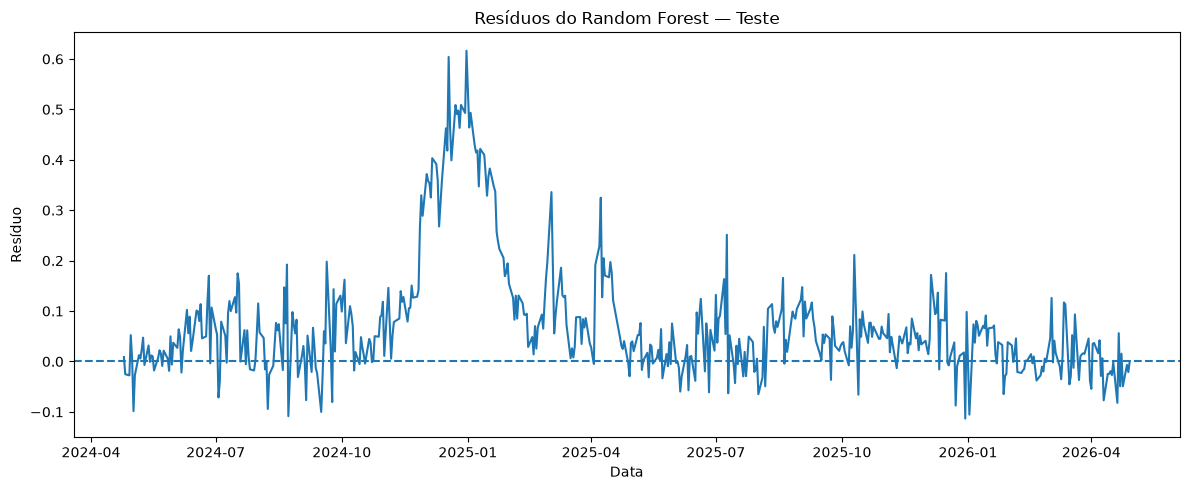

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    X_test.index,
    residuos_teste
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Resíduos do Random Forest — Teste"
)

plt.xlabel("Data")
plt.ylabel("Resíduo")

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "grafico_residuos_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Etapa 8.3 — Gráfico real × previsto — Teste

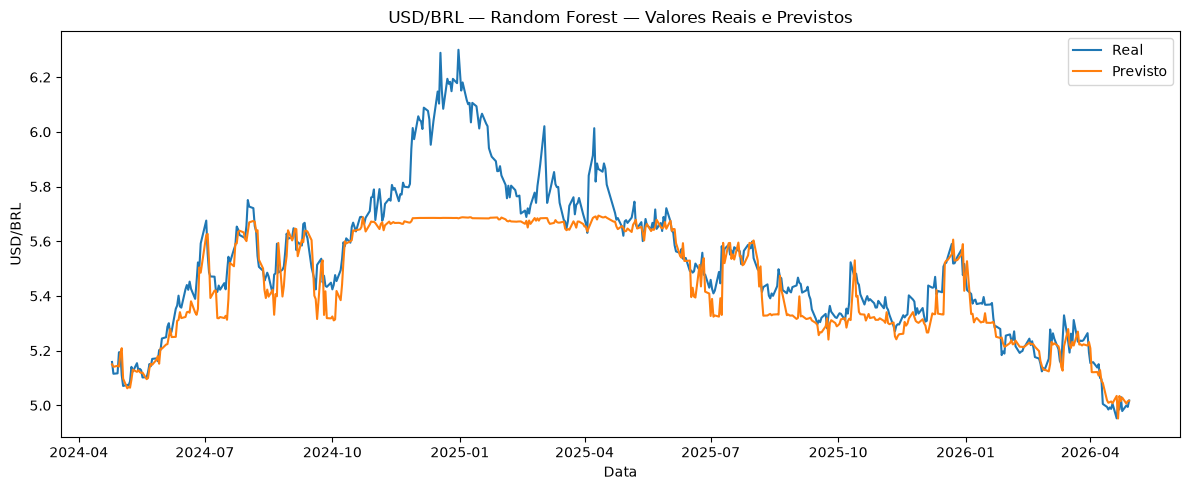

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    X_test.index,
    y_test.to_numpy(dtype=float),
    label="Real"
)

plt.plot(
    X_test.index,
    y_pred_test,
    label="Previsto"
)

plt.title(
    "USD/BRL — Random Forest — Valores Reais e Previstos"
)

plt.xlabel("Data")
plt.ylabel("USD/BRL")

plt.legend()

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "grafico_real_vs_previsto.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [40]:
y_pred_train = modelo_rf.predict(
    X_train
)

y_pred_test = modelo_rf.predict(
    X_test
)

print("[OK] Previsões de treino e teste geradas.")

previsoes_treino = pd.DataFrame({
    "Data": X_train.index,
    "Real": y_train.values,
    "Previsto": y_pred_train
})

previsoes_teste = pd.DataFrame({
    "Data": X_test.index,
    "Real": y_test.values,
    "Previsto": y_pred_test
})

display(previsoes_teste.head())


[OK] Previsões de treino e teste geradas.


,Data,Real,Previsto
0,2024-04-25,5.1586,5.149843
1,2024-04-26,5.1155,5.140826
2,2024-04-29,5.1170,5.144577
3,2024-04-30,5.1939,5.141649
4,2024-05-01,5.1944,5.189290


## Etapa 9 — Avaliação do modelo

In [41]:
def calcular_metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_real,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_real,
                y_pred
            )
        ),
        "R2": r2_score(
            y_real,
            y_pred
        )
    }


metricas_treino = calcular_metricas(
    y_train,
    y_pred_train
)

metricas_teste = calcular_metricas(
    y_test,
    y_pred_test
)

metricas = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "Random Forest"
    ],
    "Conjunto": [
        "Treino",
        "Teste"
    ],
    "MAE": [
        metricas_treino["MAE"],
        metricas_teste["MAE"]
    ],
    "RMSE": [
        metricas_treino["RMSE"],
        metricas_teste["RMSE"]
    ],
    "R2": [
        metricas_treino["R2"],
        metricas_teste["R2"]
    ]
})

display(metricas)


,Modelo,Conjunto,MAE,RMSE,R2
0,Random Forest,Treino,0.013527,0.018891,0.999530
1,Random Forest,Teste,0.086951,0.137606,0.735577


## Etapa 10 — Importância das variáveis

In [42]:
feature_importance = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance)


,Variavel,Importancia
0,USD/BRL,0.997617
1,IBOV,0.000552
2,SP500,0.000488
3,Petroleo,0.000473
4,Exportacoes,0.000185
5,IPCA,0.000165
6,PIB,0.000158
7,Importacoes,0.000144
8,Selic,0.000110
9,FEDFUNDS,0.000108


## Etapa 11 — Gráfico de importância das variáveis

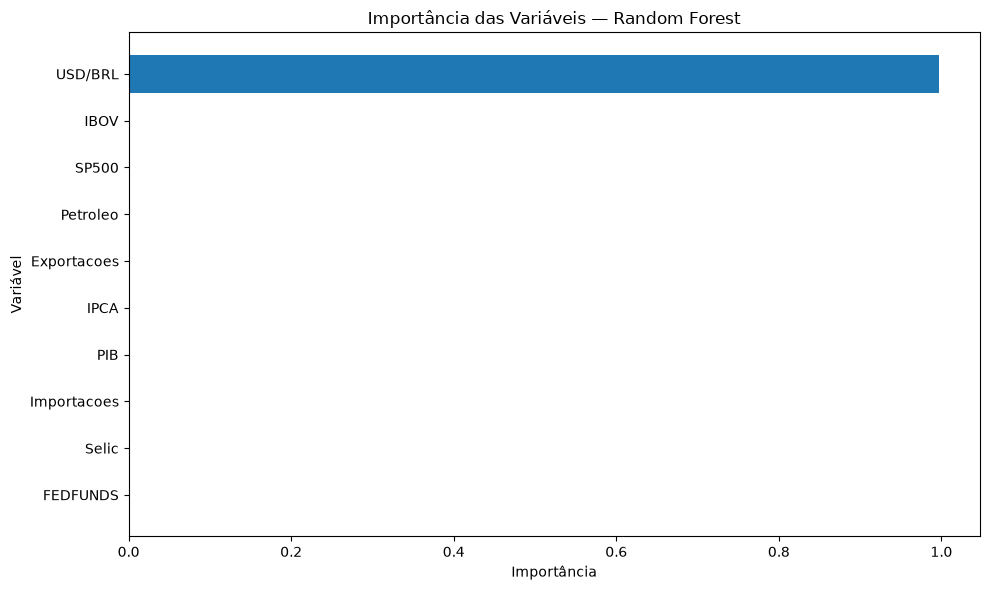

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Variavel"],
    feature_importance["Importancia"]
)

plt.gca().invert_yaxis()

plt.title(
    "Importância das Variáveis — Random Forest"
)

plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()

plt.show()


## Etapa 12 — Salvamento dos resultados

In [44]:
# ============================================================
# MÉTRICAS
# ============================================================

metricas.to_csv(
    PATH_TO_SAVE / "metricas_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# PREVISÕES
# ============================================================

previsoes_treino.to_csv(
    PATH_TO_SAVE / "previsoes_treino.csv",
    index=False,
    encoding="utf-8-sig"
)

previsoes_teste.to_csv(
    PATH_TO_SAVE / "previsoes_teste.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# RESÍDUOS
# ============================================================

residuos_treino_df.to_csv(
    PATH_TO_SAVE / "residuos_treino.csv",
    index=False,
    encoding="utf-8-sig"
)

residuos_teste_df.to_csv(
    PATH_TO_SAVE / "residuos_teste.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance.to_csv(
    PATH_TO_SAVE / "feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Variavel"],
    feature_importance["Importancia"]
)

plt.gca().invert_yaxis()

plt.title(
    "Importância das Variáveis — Random Forest"
)

plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ============================================================
# MODELO
# ============================================================

joblib.dump(
    modelo_rf,
    PATH_TO_SAVE / "random_forest.joblib"
)

print("[OK] Métricas salvas.")
print("[OK] Previsões salvas.")
print("[OK] Feature importance salva.")
print("[OK] Gráfico salvo.")
print("[OK] Modelo salvo.")
print(f"[OK] Pasta de resultados: {PATH_TO_SAVE}")


[OK] Métricas salvas.
[OK] Previsões salvas.
[OK] Feature importance salva.
[OK] Gráfico salvo.
[OK] Modelo salvo.
[OK] Pasta de resultados: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\random_forest\experimento_usd_t


## Etapa 13 — Relatório Markdown

In [45]:
linhas = []

linhas.append(
    "# Random Forest — "
    f"{NOME_EXPERIMENTO}"
)
linhas.append("")

linhas.append("## Configuração experimental")
linhas.append("")
linhas.append(
    f"- Experimento: {NOME_EXPERIMENTO}"
)
linhas.append(
    f"- Base: `{PATH_FILE}`"
)
linhas.append(
    f"- Variáveis explicativas: {len(variaveis_explicativas)}"
)
linhas.append(
    f"- Variáveis: {', '.join(variaveis_explicativas)}"
)
linhas.append(
    f"- Target: `{target}`"
)
linhas.append(
    "- Divisão temporal: 80% treino / 20% teste"
)
linhas.append(
    "- StandardScaler: não utilizado"
)
linhas.append("")

linhas.append("## Períodos")
linhas.append("")
linhas.append(
    f"- Treino: {X_train.index.min().date()} "
    f"a {X_train.index.max().date()}"
)
linhas.append(
    f"- Teste: {X_test.index.min().date()} "
    f"a {X_test.index.max().date()}"
)
linhas.append("")

linhas.append("## Hiperparâmetros")
linhas.append("")

hiperparametros = pd.DataFrame({
    "Parametro": [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features",
        "random_state",
        "n_jobs"
    ],
    "Valor": [
        500,
        "None",
        2,
        1,
        1.0,
        42,
        -1
    ]
})

linhas.append(
    hiperparametros.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Métricas")
linhas.append("")
linhas.append(
    metricas.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Importância das variáveis")
linhas.append("")
linhas.append(
    feature_importance.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Arquivos gerados")
linhas.append("")

for nome in [
    "metricas_random_forest.csv",
    "previsoes_treino.csv",
    "previsoes_teste.csv",
    "residuos_treino.csv",
    "residuos_teste.csv",
    "grafico_residuos_treino.png",
    "grafico_residuos_teste.png",
    "grafico_real_vs_previsto.png",
    "feature_importance.csv",
    "feature_importance.png",
    "random_forest.joblib",
    "random_forest.md"
]:
    linhas.append(f"- `{nome}`")

caminho_relatorio = PATH_TO_SAVE / "random_forest.md"

caminho_relatorio.write_text(
    "\n".join(linhas),
    encoding="utf-8"
)

print(
    f"[OK] Relatório salvo em:\n{caminho_relatorio}"
)


[OK] Relatório salvo em:
C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\random_forest\experimento_usd_t\random_forest.md


## Etapa 14 — Validação final dos arquivos

In [46]:
arquivos_esperados = [
    "metricas_random_forest.csv",
    "previsoes_treino.csv",
    "previsoes_teste.csv",
    "residuos_treino.csv",
    "residuos_teste.csv",
    "grafico_residuos_treino.png",
    "grafico_residuos_teste.png",
    "grafico_real_vs_previsto.png",
    "feature_importance.csv",
    "feature_importance.png",
    "random_forest.joblib",
    "random_forest.md"
]

status = pd.DataFrame({
    "Arquivo": arquivos_esperados,
    "Existe": [
        (PATH_TO_SAVE / arquivo).exists()
        for arquivo in arquivos_esperados
    ]
})

display(status)

if not status["Existe"].all():
    faltantes = status.loc[
        ~status["Existe"],
        "Arquivo"
    ].tolist()

    raise FileNotFoundError(
        f"Arquivos não encontrados: {faltantes}"
    )

print("\n[OK] Execução concluída com todos os arquivos esperados.")
print(f"[OK] Resultados em: {PATH_TO_SAVE}")


,Arquivo,Existe
0,metricas_random_forest.csv,True
1,previsoes_treino.csv,True
2,previsoes_teste.csv,True
3,residuos_treino.csv,True
4,residuos_teste.csv,True
5,grafico_residuos_treino.png,True
6,grafico_residuos_teste.png,True
7,grafico_real_vs_previsto.png,True
8,feature_importance.csv,True
9,feature_importance.png,True



[OK] Execução concluída com todos os arquivos esperados.
[OK] Resultados em: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\random_forest\experimento_usd_t


## Resultado da execução

Este notebook mantém a especificação do Random Forest definida no arquivo `10_Random_Forest.ipynb`, mas organiza o fluxo no mesmo padrão modular do notebook `05_regressao_linear.ipynb`: configuração, preparação, treinamento, previsões, avaliação, importância das variáveis, salvamento, relatório e validação final.